# Research Paper Summarization — TextRank (Extractive Baseline)



> **Dataset:** `ccdv/pubmed-summarization` (PubMed) dari Hugging Face  
> **Model:** TextRank via `sumy` library

---
## 0. Install Dependencies

In [1]:
!pip install sumy datasets rouge-score nltk -q
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
print('Dependencies siap!')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 83.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 141.4 MB/s eta 0:00:0000:01
Dependencies siap!


---
## 1. Dataset Preparation

Sama seperti model lain: `ccdv/pubmed-summarization`, kolom `article` dan `abstract`.

In [2]:
from datasets import load_dataset
import pandas as pd

print('Loading dataset PubMed dari Hugging Face...')
print('Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization')

dataset = load_dataset('ccdv/pubmed-summarization')

print('\nDataset splits tersedia:')
print(dataset)
print(f'\nJumlah data:')
print(f'  Train      : {len(dataset["train"]):,}')
print(f'  Validation : {len(dataset["validation"]):,}')
print(f'  Test       : {len(dataset["test"]):,}')


Loading dataset PubMed dari Hugging Face...
Ref: https://huggingface.co/datasets/ccdv/pubmed-summarization


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]


Dataset splits tersedia:
DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})

Jumlah data:
  Train      : 119,924
  Validation : 6,633
  Test       : 6,658


In [3]:
# Mapping ke input_text dan target_text sesuai proposal
def map_columns(example):
    return {
        'input_text': example['article'],
        'target_text': example['abstract']
    }

dataset = dataset.map(map_columns, remove_columns=['article', 'abstract'])

print('Kolom setelah mapping:', dataset['train'].column_names)


Map:   0%|          | 0/119924 [00:00<?, ? examples/s]

Map:   0%|          | 0/6633 [00:00<?, ? examples/s]

Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Kolom setelah mapping: ['input_text', 'target_text']


In [4]:
# Subset kecil sesuai proposal (debug dulu)
DEBUG_MODE = True
EVAL_SIZE  = 500

if DEBUG_MODE:
    test_data = dataset['test'].select(range(EVAL_SIZE))
    print(f'[DEBUG MODE] Test samples: {len(test_data)}')
else:
    test_data = dataset['test']
    print(f'[FULL MODE] Test samples: {len(test_data)}')

# Lihat contoh data
sample = test_data[0]
print(f'\nPanjang article : {len(sample["input_text"].split())} kata')
print(f'Panjang abstract: {len(sample["target_text"].split())} kata')


[DEBUG MODE] Test samples: 500

Panjang article : 3146 kata
Panjang abstract: 213 kata


---
## 2. TextRank — Extractive Summarization

TextRank **tidak perlu preprocessing tokenisasi seperti model neural** — langsung proses teks mentah.

Yang dilakukan:
- Cleaning minimal (rapikan spasi)
- TextRank graph ranking via `sumy`
- Output: kalimat-kalimat terpenting dari artikel

> ⚠️ Extractive = kalimat diambil langsung dari artikel, bukan di-generate ulang.

In [5]:
import re

def clean_text(text):
    """Cleaning minimal — rapikan spasi dan newline."""
    if isinstance(text, list):
        text = ' '.join(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Test
sample_clean = clean_text(test_data[0]['input_text'])
print(f'Panjang setelah cleaning: {len(sample_clean.split())} kata')
print('Preview:', sample_clean[:200])


Panjang setelah cleaning: 3146 kata
Preview: anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depressi


In [6]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

LANGUAGE = 'english'
# Jumlah kalimat yang diambil — sesuaikan dengan panjang abstrak referensi
NUM_SENTENCES = 5

def textrank_summarize(text, num_sentences=NUM_SENTENCES):
    """
    Generate ringkasan extractive menggunakan TextRank.
    Input: teks artikel mentah
    Output: string ringkasan (kalimat-kalimat terpenting)
    """
    text = clean_text(text)

    # Kalau teks terlalu pendek, return as-is
    if len(text.split()) < 50:
        return text

    try:
        parser = PlaintextParser.from_string(text, Tokenizer(LANGUAGE))
        stemmer = Stemmer(LANGUAGE)
        summarizer = TextRankSummarizer(stemmer)
        summarizer.stop_words = get_stop_words(LANGUAGE)

        summary = summarizer(parser.document, num_sentences)
        return ' '.join(str(sentence) for sentence in summary)
    except Exception as e:
        # Fallback: ambil N kalimat pertama
        sentences = text.split('. ')
        return '. '.join(sentences[:num_sentences])

# Test pada satu sampel
sample = test_data[0]
print('=== Test TextRank ===')
print(f'Input ({len(sample["input_text"].split())} kata):')
print(' '.join(sample['input_text'].split()[:80]) + '...')
print('\n--- Generated Summary ---')
generated = textrank_summarize(sample['input_text'])
print(generated)
print('\n--- Reference Abstract ---')
print(sample['target_text'])


=== Test TextRank ===
Input (3146 kata):
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and coexist in pd patients , recent research suggests that anxiety rather than depression is the most prominent and prevalent mood disorder in pd [ 5 , 6 ] . yet , our current understanding of anxiety and its impact...

--- Generated Summary ---
the first study found that working memory performance was worse in lpd patients with anxiety compared to rpd patients with anxiety , whereas the second study reported that , in lpd , apathy but not anxiety was associated with performance on nonverbally mediated executive functions and visuospatial tasks ( e.g. , tmt - b , wms - iii spatial span ) , while in rpd , anxiety but not apathy significantly correlated with performance on verbally mediated tasks ( e.g. , clock reading test and bo

---
## 3. Inference — Generate Semua Ringkasan

TextRank tidak perlu training — langsung inference semua test data.

In [7]:
print('Generating ringkasan TextRank untuk semua test data...')
print('(Tidak ada training — langsung inference)')
print('=' * 50)

generated_summaries = []
reference_summaries = []

for i, sample in enumerate(test_data):
    gen = textrank_summarize(sample['input_text'])
    generated_summaries.append(gen)
    reference_summaries.append(sample['target_text'])

    if (i + 1) % 20 == 0 or (i + 1) == len(test_data):
        print(f'  Progress: {i+1}/{len(test_data)}')

print(f'\nSelesai! Total ringkasan: {len(generated_summaries)}')


Generating ringkasan TextRank untuk semua test data...
(Tidak ada training — langsung inference)
  Progress: 20/500
  Progress: 40/500
  Progress: 60/500
  Progress: 80/500
  Progress: 100/500
  Progress: 120/500
  Progress: 140/500
  Progress: 160/500
  Progress: 180/500
  Progress: 200/500
  Progress: 220/500
  Progress: 240/500
  Progress: 260/500
  Progress: 280/500
  Progress: 300/500
  Progress: 320/500
  Progress: 340/500
  Progress: 360/500
  Progress: 380/500
  Progress: 400/500
  Progress: 420/500
  Progress: 440/500
  Progress: 460/500
  Progress: 480/500
  Progress: 500/500

Selesai! Total ringkasan: 500


---
## 4. Evaluation

Evaluasi menggunakan **ROUGE-1, ROUGE-2, ROUGE-L** sesuai proposal.

> Catatan: TextRank extractive cenderung dapat ROUGE-1 tinggi (kata sama persis dari artikel),
> tapi ROUGE-2 dan ROUGE-L lebih rendah karena kalimatnya panjang dan tidak koheren seperti abstrak.

In [8]:
from rouge_score import rouge_scorer
import numpy as np

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores['rouge1'].append(score['rouge1'].fmeasure)
        scores['rouge2'].append(score['rouge2'].fmeasure)
        scores['rougeL'].append(score['rougeL'].fmeasure)

    return {
        'ROUGE-1': round(np.mean(scores['rouge1']) * 100, 2),
        'ROUGE-2': round(np.mean(scores['rouge2']) * 100, 2),
        'ROUGE-L': round(np.mean(scores['rougeL']) * 100, 2),
    }

print('Menghitung ROUGE scores...')
rouge_scores = compute_rouge(generated_summaries, reference_summaries)

print('\n' + '=' * 40)
print('     HASIL EVALUASI — TextRank')
print('=' * 40)
for metric, score in rouge_scores.items():
    print(f'  {metric} : {score:.2f}')
print('=' * 40)
print('(Skala 0-100, semakin tinggi semakin baik)')


Menghitung ROUGE scores...

     HASIL EVALUASI — TextRank
  ROUGE-1 : 39.31
  ROUGE-2 : 14.32
  ROUGE-L : 21.06
(Skala 0-100, semakin tinggi semakin baik)


In [9]:
# Simpan hasil ke CSV untuk comparative analysis
results_df = pd.DataFrame([{
    'Model': 'TextRank (sumy)',
    'ROUGE-1': rouge_scores['ROUGE-1'],
    'ROUGE-2': rouge_scores['ROUGE-2'],
    'ROUGE-L': rouge_scores['ROUGE-L'],
    'Tipe': 'Extractive Baseline',
    'Dataset': 'PubMed (ccdv/pubmed-summarization)',
    'Test Samples': len(test_data),
    'Training Required': 'Tidak'
}])

results_df.to_csv('textrank_rouge_results.csv', index=False)
print('Hasil disimpan ke: textrank_rouge_results.csv')
results_df


Hasil disimpan ke: textrank_rouge_results.csv


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Tipe,Dataset,Test Samples,Training Required
0,TextRank (sumy),39.31,14.32,21.06,Extractive Baseline,PubMed (ccdv/pubmed-summarization),500,Tidak


---
## 📊 Visualisasi & Metric Evaluation

Visualisasi hasil evaluasi model: ROUGE scores, distribusi per sampel, analisis panjang, dan training curves.

In [11]:
# TextRank tidak pakai neural model
MODEL_NAME = "TextRank (sumy)"

In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from rouge_score import rouge_scorer as rs_mod

# ── Hitung score per sampel ──
sc = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
per_sample = {'ROUGE-1': [], 'ROUGE-2': [], 'ROUGE-L': []}
for pred, ref in zip(generated_summaries, reference_summaries):
    s = sc.score(ref, pred)
    per_sample['ROUGE-1'].append(s['rouge1'].fmeasure * 100)
    per_sample['ROUGE-2'].append(s['rouge2'].fmeasure * 100)
    per_sample['ROUGE-L'].append(s['rougeL'].fmeasure * 100)

# ── Plot 1: ROUGE Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'ROUGE Evaluation — {MODEL_NAME}', fontsize=13, fontweight='bold')

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [rouge_scores[m] for m in metrics]
colors  = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(metrics, scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylim(0, max(scores) * 1.35)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_title('ROUGE Scores (Average)')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 2: Distribusi ROUGE-1 (Histogram) ──
axes[1].hist(per_sample['ROUGE-1'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(per_sample['ROUGE-1']), color='tomato', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(per_sample["ROUGE-1"]):.2f}')
axes[1].set_xlabel('ROUGE-1 F1 Score (%)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi ROUGE-1 per Sampel')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./viz_rouge_bar_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_bar_hist.png")


Saved: viz_rouge_bar_hist.png


In [13]:
# ── Plot 3: Boxplot semua metrik ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Score Distribution — {MODEL_NAME}', fontsize=12, fontweight='bold')

bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (%)')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, vals) in enumerate(per_sample.items(), 1):
    med = np.median(vals)
    ax.text(i, med + 0.3, f'{med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_rouge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_boxplot.png")


Saved: viz_rouge_boxplot.png


/tmp/ipykernel_1971/525352208.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),


In [14]:
# ── Plot 4: Panjang Input vs ROUGE-1 & Generated vs Reference ──
input_lengths = [len(sample['input_text'].split()) for sample in test_data]
gen_lengths   = [len(s.split()) for s in generated_summaries]
ref_lengths   = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Length Analysis — {MODEL_NAME}', fontsize=13, fontweight='bold')

# Scatter: input length vs ROUGE-1
axes[0].scatter(input_lengths, per_sample['ROUGE-1'], alpha=0.4, color='#4C72B0', s=18)
z = np.polyfit(input_lengths, per_sample['ROUGE-1'], 1)
x_line = np.linspace(min(input_lengths), max(input_lengths), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='tomato', linewidth=2,
            linestyle='--', label='Trend')
axes[0].set_xlabel('Panjang Input (kata)')
axes[0].set_ylabel('ROUGE-1 (%)')
axes[0].set_title('Panjang Input vs ROUGE-1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: generated vs reference length
avg_gen, avg_ref = np.mean(gen_lengths), np.mean(ref_lengths)
bars = axes[1].bar(['Generated\nSummary', 'Reference\nAbstract'],
                   [avg_gen, avg_ref],
                   color=['#4C72B0', '#55A868'], width=0.4, edgecolor='white')
axes[1].set_ylabel('Rata-rata Panjang (kata)')
axes[1].set_title('Panjang Generated vs Reference')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, [avg_gen, avg_ref]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./viz_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_length_analysis.png")


Saved: viz_length_analysis.png


---
## 📺 Tampilkan Visualisasi

Total visualisasi: 3

📊 Length Analysis


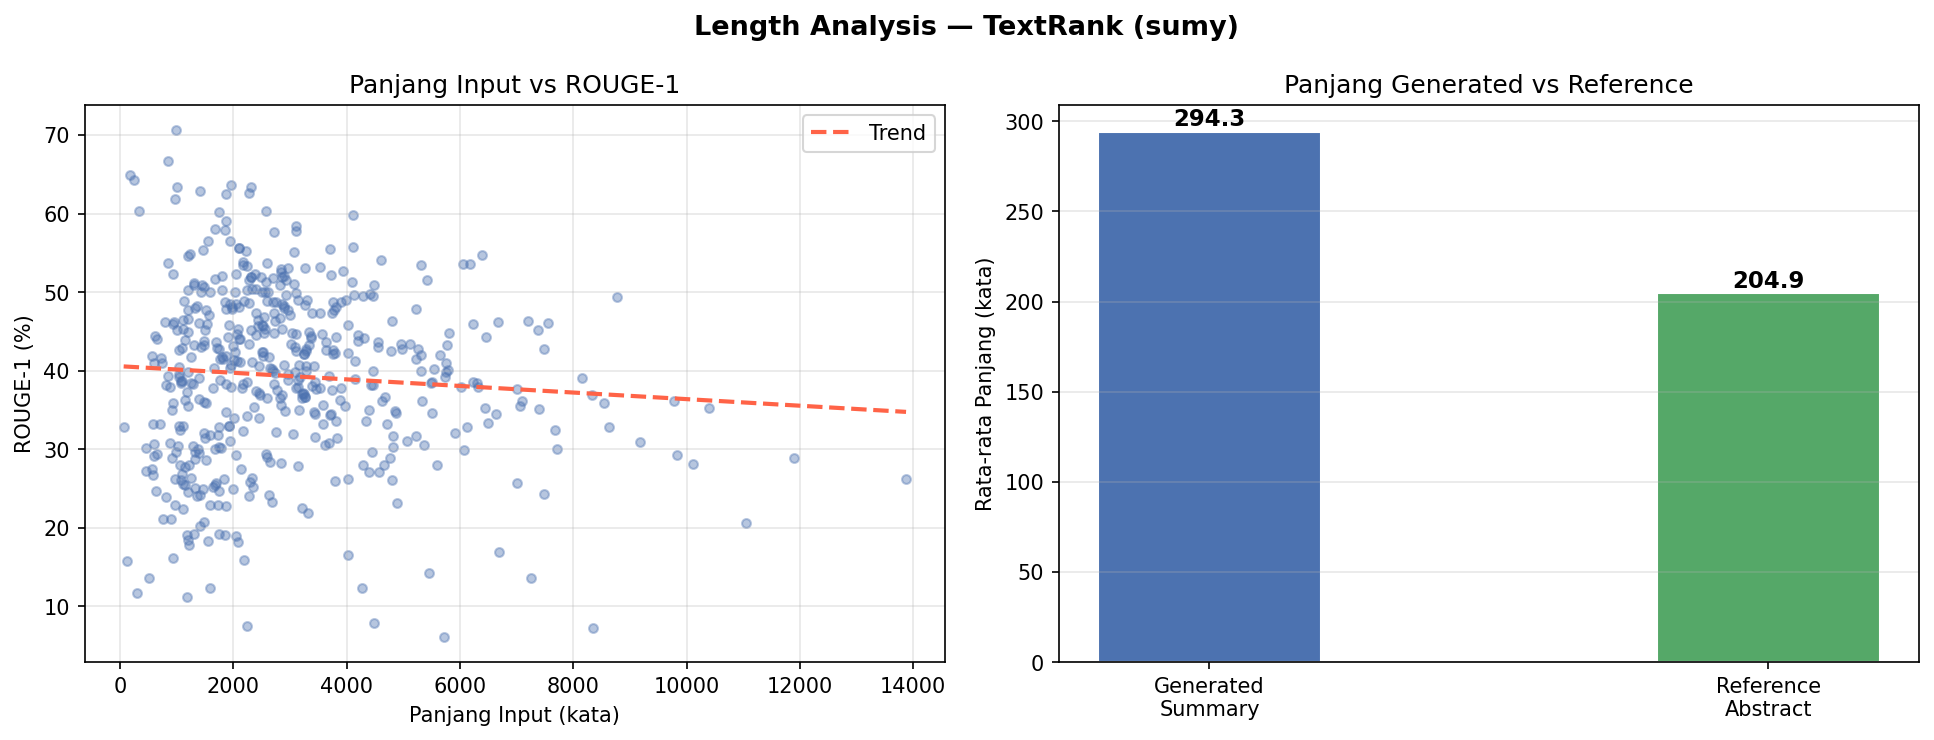


📊 Rouge Bar Hist


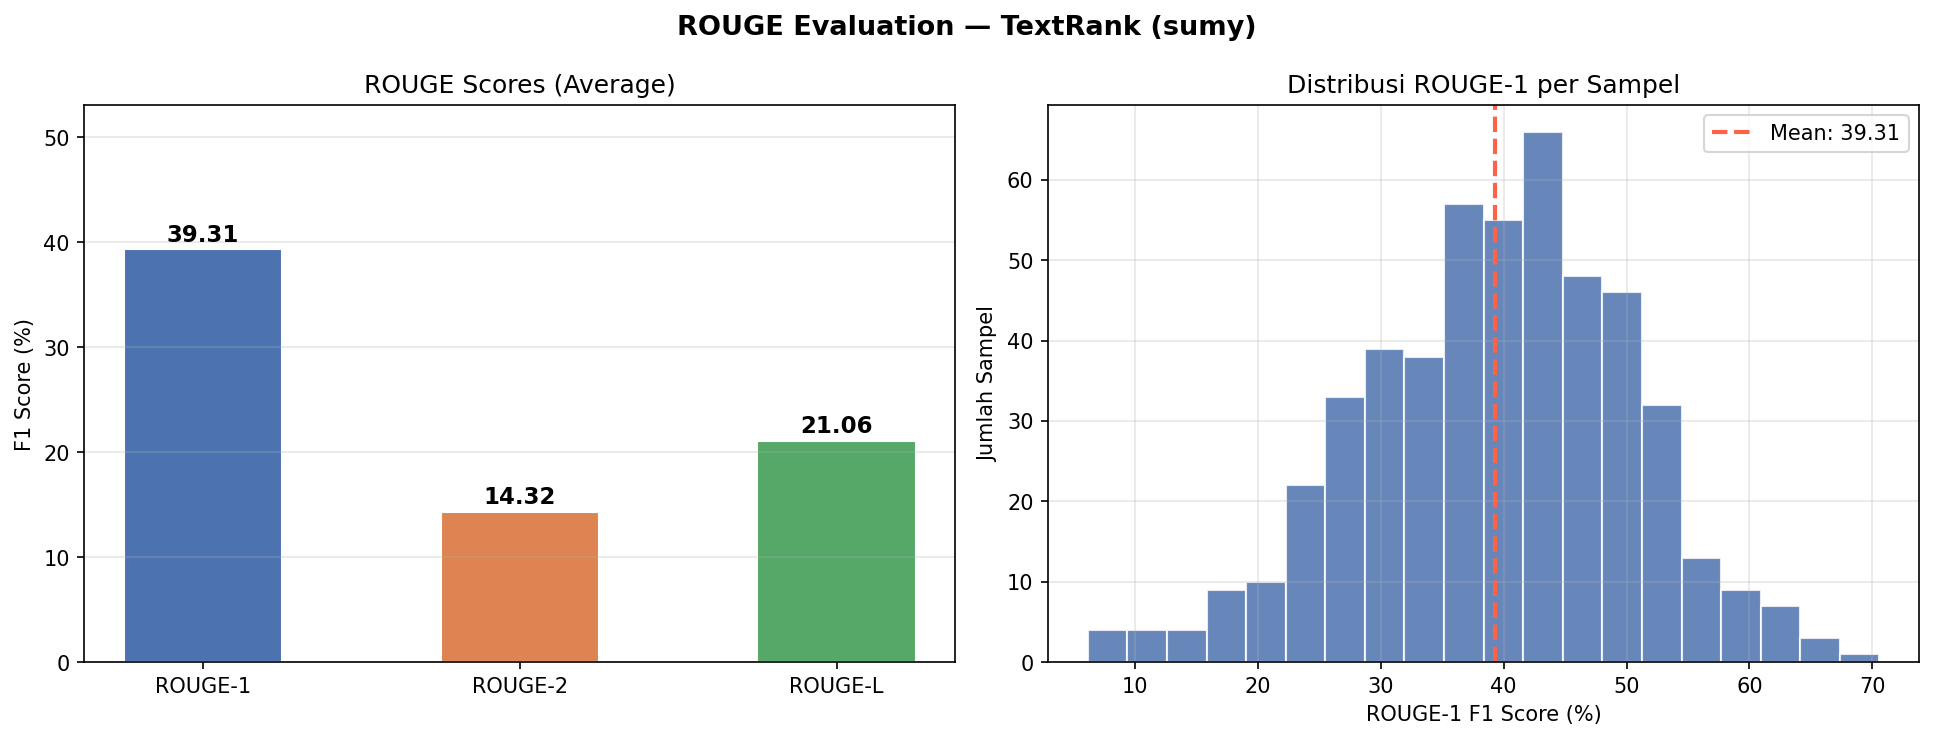


📊 Rouge Boxplot


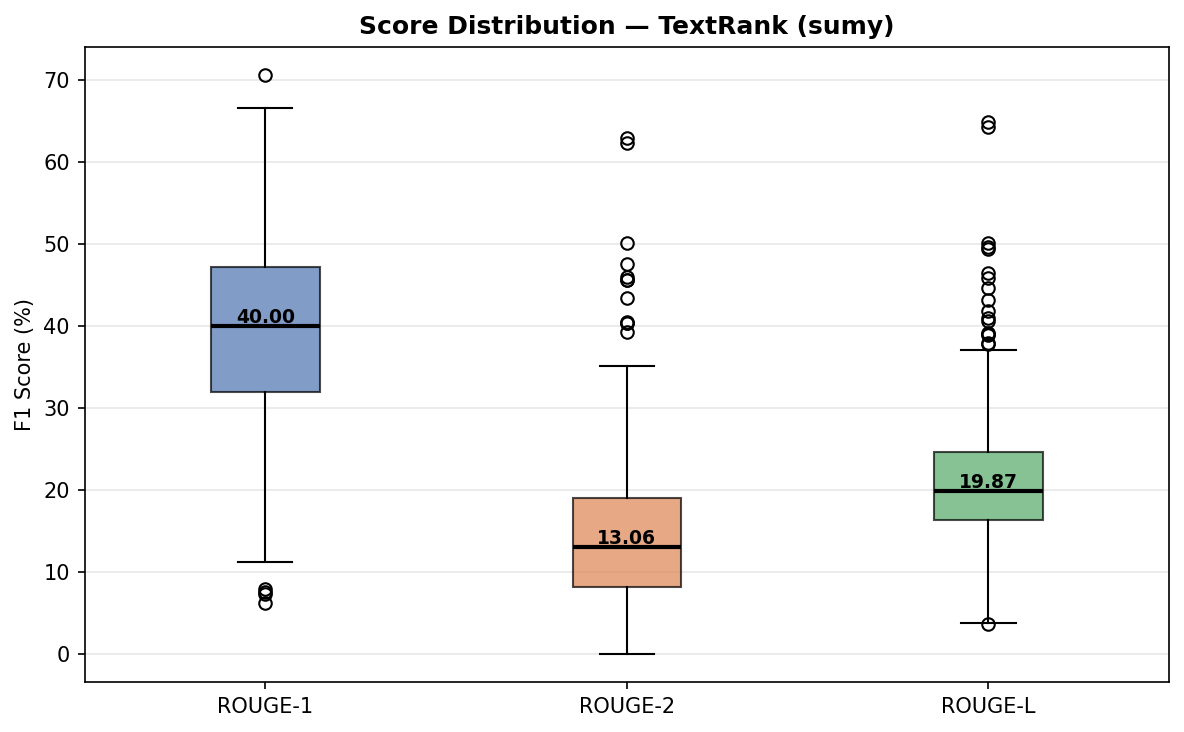

In [15]:
from IPython.display import display, Image
import glob

# ── Tampilkan semua visualisasi ──
viz_files = sorted(glob.glob('./viz_*.png'))
print(f"Total visualisasi: {len(viz_files)}")
print("=" * 50)

for f in viz_files:
    name = f.replace('./viz_', '').replace('.png', '').replace('_', ' ').title()
    print(f"\n📊 {name}")
    display(Image(filename=f, width=900))


In [18]:
import json

output_data = {
    'model': 'TextRank',
    'library': 'sumy',
    'dataset': 'PubMed (ccdv/pubmed-summarization)',
    'rouge_scores': rouge_scores,
    'num_test_samples': len(test_data),
    'num_sentences': NUM_SENTENCES,
    'training_required': False,
    'predictions': generated_summaries,
    'references': reference_summaries
}

with open('textrank_predictions.json', 'w') as f:
    json.dump(output_data, f, indent=2)

with open('textrank_rouge_results.csv', 'w') as f:
    f.write('Model,ROUGE-1,ROUGE-2,ROUGE-L\n')
    f.write(f'TextRank,{rouge_scores["ROUGE-1"]},{rouge_scores["ROUGE-2"]},{rouge_scores["ROUGE-L"]}\n')

print('✅ File saved!')
print('  - textrank_predictions.json')
print('  - textrank_rouge_results.csv')

✅ File saved!
  - textrank_predictions.json
  - textrank_rouge_results.csv


---
## 💾 Simpan Hasil ke Google Drive

In [19]:
from google.colab import drive
import shutil, os, glob

# Mount Google Drive
drive.mount('/content/drive')

# ── Path tujuan di Drive ──
DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/Textrank'
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── Simpan visualisasi ke Drive ──
viz_files = glob.glob('./viz_*.png')
for f in viz_files:
    shutil.copy(f, DRIVE_PATH)
    print(f'  ✅ {f} → Drive')

# ── Simpan hasil evaluasi ke Drive ──
shutil.copy('textrank_rouge_results.csv', DRIVE_PATH)
shutil.copy('textrank_predictions.json', DRIVE_PATH)
print(f'  ✅ textrank_rouge_results.csv → Drive')
print(f'  ✅ textrank_predictions.json → Drive')

print(f'\n✅ Semua hasil disimpan ke: {DRIVE_PATH}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ ./viz_rouge_boxplot.png → Drive
  ✅ ./viz_length_analysis.png → Drive
  ✅ ./viz_rouge_bar_hist.png → Drive
  ✅ textrank_rouge_results.csv → Drive
  ✅ textrank_predictions.json → Drive

✅ Semua hasil disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/Textrank


---
## 6. Simpan Hasil untuk Comparative Analysis

In [22]:
import json

output_data = {
    'model': 'TextRank',
    'library': 'sumy',
    'dataset': 'PubMed (ccdv/pubmed-summarization)',
    'rouge_scores': rouge_scores,
    'num_test_samples': len(test_data),
    'num_sentences': NUM_SENTENCES,
    'training_required': False,
    'predictions': generated_summaries,
    'references': reference_summaries
}

with open('textrank_predictions.json', 'w') as f:
    json.dump(output_data, f, indent=2)

print('Hasil disimpan ke: textrank_predictions.json')
print('\n✅ Pipeline TextRank selesai! Summary:')
print(f'  Model    : TextRank (sumy)')
print(f'  Dataset  : PubMed (ccdv/pubmed-summarization)')
print(f'  ROUGE-1  : {rouge_scores["ROUGE-1"]}')
print(f'  ROUGE-2  : {rouge_scores["ROUGE-2"]}')
print(f'  ROUGE-L  : {rouge_scores["ROUGE-L"]}')
print(f'  Training : Tidak diperlukan')


Hasil disimpan ke: textrank_predictions.json

✅ Pipeline TextRank selesai! Summary:
  Model    : TextRank (sumy)
  Dataset  : PubMed (ccdv/pubmed-summarization)
  ROUGE-1  : 39.31
  ROUGE-2  : 14.32
  ROUGE-L  : 21.06
  Training : Tidak diperlukan


In [23]:
import shutil, os

# Buat folder khusus output TextRank
os.makedirs("/content/textrank_output", exist_ok=True)

# Copy semua hasil ke folder
shutil.copy("textrank_rouge_results.csv", "/content/textrank_output/")
shutil.copy("textrank_predictions.json", "/content/textrank_output/")

# Zip foldernya
shutil.make_archive(
    "/content/textrank_output",  # nama zip
    "zip",
    "/content",
    "textrank_output"                   # folder yang di-zip
)

print("✅ Done! File: /content/textrank_output.zip")
print(f"   - textrank_rouge_results.csv")
print(f"   - textrank_predictions.json")

✅ Done! File: /content/textrank_output.zip
   - textrank_rouge_results.csv
   - textrank_predictions.json
